В данном ноутбуке проведем сегментационный анализ удержания:
- сравним удержание клиентов между различными сегментами
- выявим различия в поведении
- сформулируем продуктовые гипотезы

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv("raw_files/customers.csv")

In [4]:
pd.set_option("display.float_format", "{:.3f}".format)

tx = pd.read_csv("processed_files/transactions_with_cohorts.csv")
tx["t_dat"] = pd.to_datetime(tx["t_dat"])
tx["first_purchase_date"] = pd.to_datetime(tx["first_purchase_date"])

tx.head()

,customer_id,t_dat,first_purchase_date,cohort_month,days_since_first_purchase
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0


Сделаем сегментацию по возрастным группам

In [5]:
tx_with_age = tx.merge(customers, on = "customer_id", how = "left")
tx_with_age.head(5)

,customer_id,t_dat,first_purchase_date,cohort_month,days_since_first_purchase,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0,NaN,NaN,ACTIVE,NONE,24.000,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0,NaN,NaN,ACTIVE,NONE,24.000,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...


In [6]:
bins = [0, 25, 35, 50, 100]
labels = ["<25", "25-35", "35-50", "50+"]

tx_with_age["age_group"] = pd.cut(tx_with_age["age"], bins=bins, labels=labels)
tx_with_age.head()

,customer_id,t_dat,first_purchase_date,cohort_month,days_since_first_purchase,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,age_group
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0,NaN,NaN,ACTIVE,NONE,24.000,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,<25
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2018-09-20,2018-09,0,NaN,NaN,ACTIVE,NONE,24.000,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,<25
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...,25-35
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...,25-35
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,2018-09-20,2018-09-20,2018-09,0,1.000,1.000,ACTIVE,Regularly,32.000,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...,25-35


In [7]:
def retention_by_age(df, days = [7, 30, 90]):
    results = []

    for group in df["age_group"].dropna().unique():
        df_seg = df[df["age_group"] == group]
        cohort_sizes = (df_seg.groupby("cohort_month")["customer_id"].nunique())

        for d in days:
            retained = (
                df_seg[
                    (df_seg["days_since_first_purchase"] >= 1) &
                    (df_seg["days_since_first_purchase"] <= d)
                ]
                .groupby("cohort_month")["customer_id"]
                .nunique()
            )

            retention = (retained / cohort_sizes).mean()

            results.append({
                "age_group": group,
                "day": f"D{d}",
                "retention": retention
            })

    return pd.DataFrame(results)

In [8]:
age_ret = retention_by_age(tx_with_age)
age_ret

,age_group,day,retention
0,<25,D7,0.106
1,<25,D30,0.232
2,<25,D90,0.394
3,25-35,D7,0.112
4,25-35,D30,0.234
5,25-35,D90,0.384
6,35-50,D7,0.110
7,35-50,D30,0.221
8,35-50,D90,0.351
9,50+,D7,0.116


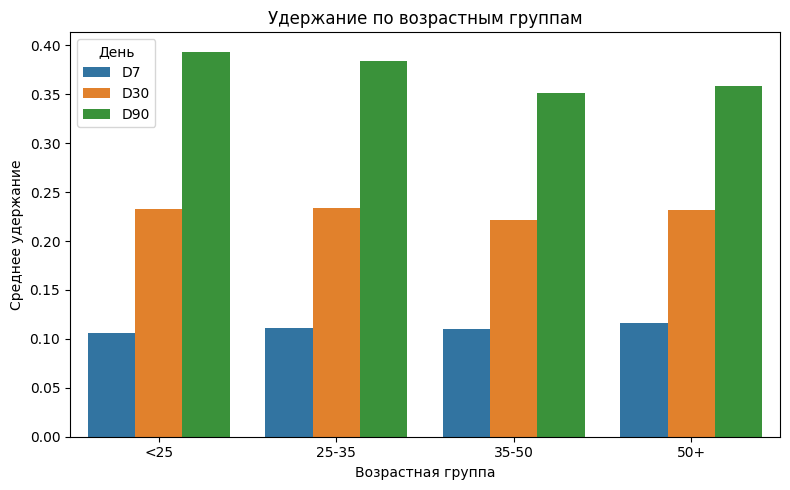

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_ret,
    x="age_group",
    y="retention",
    hue="day"
)

plt.title("Удержание по возрастным группам")
plt.ylabel("Среднее удержание")
plt.xlabel("Возрастная группа")
plt.legend(title="День")
plt.tight_layout()
plt.show()


Делаем флаг возврата на 30-й день

In [10]:
d = 30

returned = (
    tx[
        (tx["days_since_first_purchase"] >= 1) &
        (tx["days_since_first_purchase"] <= d)
    ]
    .groupby("customer_id")["customer_id"]
    .nunique()
)

returned_ids = returned.index

tx["returned_d30"] = tx["customer_id"].isin(returned_ids)

Добавляем к нашему датафрейму tx_with_age колонку returned_d30

In [11]:
tx_with_age = tx_with_age.merge(
    tx[["customer_id", "returned_d30"]].drop_duplicates(),
    on="customer_id",
    how="left"
)

Создаем таблицу клиентов по возрасту

In [12]:
clients = tx_with_age[["customer_id", "age_group", "returned_d30"]].drop_duplicates()

summary = (
    clients.groupby("age_group")["returned_d30"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "returned", "count": "total"})
)

summary["not_returned"] = summary["total"] - summary["returned"]
summary["retention"] = summary["returned"] / summary["total"]

summary

C:\Users\dlyan\AppData\Local\Temp\ipykernel_11240\1955599157.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clients.groupby("age_group")["returned_d30"]


,returned,total,not_returned,retention
age_group,,,,
<25,109985,408509,298524,0.269
25-35,105055,356083,251028,0.295
35-50,80506,294829,214323,0.273
50+,81282,287099,205817,0.283


Проводим хи-квадрат тест для всех возрастных групп

In [13]:
from scipy.stats import chi2_contingency

contingency_table = summary[["returned", "not_returned"]]

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.10f}")
print(f"degrees of freedom: {dof}")

Chi-square statistic: 718.135
p-value: 0.0000000000
degrees of freedom: 3


Для проверки различий в удержании между возрастными группами был применён критерий хи-квадрат. Полученное значение p-value < 0.05 показало наличие статистически значимых различий между возрастными сегментами. 
Однако абсолютные различия в retention невелики: значения удержания находятся в близком диапазоне, поэтому практическое влияние возраста на удержание клиентов можно считать умеренным.

In [14]:
summary[["retention"]]

,retention
age_group,
<25,0.269
25-35,0.295
35-50,0.273
50+,0.283


Максимальное удержание наблюдаем у группы 25-35, минимальное у 35-50, различия статистически значимы, но эффект слабый практически.

In [15]:
summary.to_csv("processed_files/age_summary.csv")